# 03. Классификатор обычных и тонких срастаний

Ноутбук обучает baseline-классификатор `ordinary / fine` на очищенном manifest.

Архитектура: `MobileNetV3-Small` с предобученными весами ImageNet.

Почему эта модель:

- достаточно лёгкая для ноутбука;
- быстро обучается;
- подходит для последующего tile-wise inference на панорамах;
- сохраняет вероятности классов для карты уверенности.

Перед запуском должен быть выполнен `02_prepare_training_data.ipynb`.

In [1]:
from pathlib import Path

MANIFEST_PATH = Path(
    "data/processed/manifests/classifier_manifest_clean.csv"
)

OUTPUT_DIR = Path("outputs/classifier")
MODEL_DIR = Path("models")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

assert MANIFEST_PATH.exists(), (
    f"Не найден manifest: {MANIFEST_PATH}\n"
    "Сначала выполните 02_prepare_training_data.ipynb."
)

# Основные параметры.
IMAGE_SIZE = 224
BATCH_SIZE = 24
HEAD_EPOCHS = 4
FINETUNE_EPOCHS = 4
LEARNING_RATE_HEAD = 1e-3
LEARNING_RATE_FINETUNE = 2e-4
WEIGHT_DECAY = 1e-4
RANDOM_SEED = 42

print("Manifest:", MANIFEST_PATH.resolve())
print("Output:", OUTPUT_DIR.resolve())

Manifest: C:\Users\Мария\ore_hackathon\data\processed\manifests\classifier_manifest_clean.csv
Output: C:\Users\Мария\ore_hackathon\outputs\classifier


In [2]:
import json
import os
import random
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image, ImageOps
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
Image.MAX_IMAGE_PIXELS = None


def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(RANDOM_SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch:", torch.__version__)
print("Устройство:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.12.1+cpu
Устройство: cpu


## 1. Загрузка и проверка manifest

In [3]:
manifest = pd.read_csv(
    MANIFEST_PATH,
    encoding="utf-8-sig",
)

required_columns = {
    "absolute_path",
    "filename",
    "label",
    "split",
    "sample_group",
}

missing = required_columns.difference(manifest.columns)
assert not missing, f"В manifest отсутствуют колонки: {missing}"

manifest = manifest[
    manifest["label"].isin(["ordinary", "fine"])
].copy()

manifest["absolute_path"] = manifest["absolute_path"].astype(str)

missing_files = manifest[
    ~manifest["absolute_path"].map(
        lambda path: Path(path).exists()
    )
]

assert missing_files.empty, (
    f"Не найдено файлов: {len(missing_files)}.\n"
    "Проверьте, что датасет не перемещался после аудита.\n"
    f"Первый пример: {missing_files.iloc[0]['absolute_path']}"
)

display(
    manifest.groupby(
        ["split", "label"]
    ).size().unstack(fill_value=0)
)

leakage = (
    manifest.groupby("sample_group")["split"]
    .nunique()
    .gt(1)
    .sum()
)

assert leakage == 0, (
    f"Обнаружена утечка групп между split: {leakage}"
)

print("Утечки sample_group между split нет.")

label,fine,ordinary
split,,
test,51,57
train,338,388
validation,70,89


Утечки sample_group между split нет.


## 2. Dataset и аугментации

Цветовые аугментации намеренно умеренные: цвет и яркость содержат полезную информацию, но модель должна выдерживать разницу между микроскопами и условиями съёмки.

In [4]:
LABEL_TO_ID = {
    "fine": 0,
    "ordinary": 1,
}

ID_TO_LABEL = {
    value: key
    for key, value in LABEL_TO_ID.items()
}


train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.70, 1.0),
        ratio=(0.85, 1.15),
    ),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.18,
        contrast=0.18,
        saturation=0.10,
        hue=0.02,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


class OreDataset(Dataset):
    def __init__(
        self,
        frame: pd.DataFrame,
        transform,
    ):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, index: int):
        row = self.frame.iloc[index]

        with Image.open(row["absolute_path"]) as image:
            image = ImageOps.exif_transpose(
                image
            ).convert("RGB")

        image_tensor = self.transform(image)
        label_id = LABEL_TO_ID[row["label"]]

        return {
            "image": image_tensor,
            "label": torch.tensor(
                label_id,
                dtype=torch.long,
            ),
            "path": row["absolute_path"],
            "filename": row["filename"],
        }


frames = {
    split: manifest[
        manifest["split"] == split
    ].copy()
    for split in ["train", "validation", "test"]
}

datasets = {
    "train": OreDataset(
        frames["train"],
        train_transform,
    ),
    "validation": OreDataset(
        frames["validation"],
        eval_transform,
    ),
    "test": OreDataset(
        frames["test"],
        eval_transform,
    ),
}

loaders = {
    split: DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=(split == "train"),
        num_workers=0,
        pin_memory=(DEVICE.type == "cuda"),
    )
    for split, dataset in datasets.items()
}

print({
    split: len(dataset)
    for split, dataset in datasets.items()
})

{'train': 726, 'validation': 159, 'test': 108}


## 3. Просмотр аугментаций

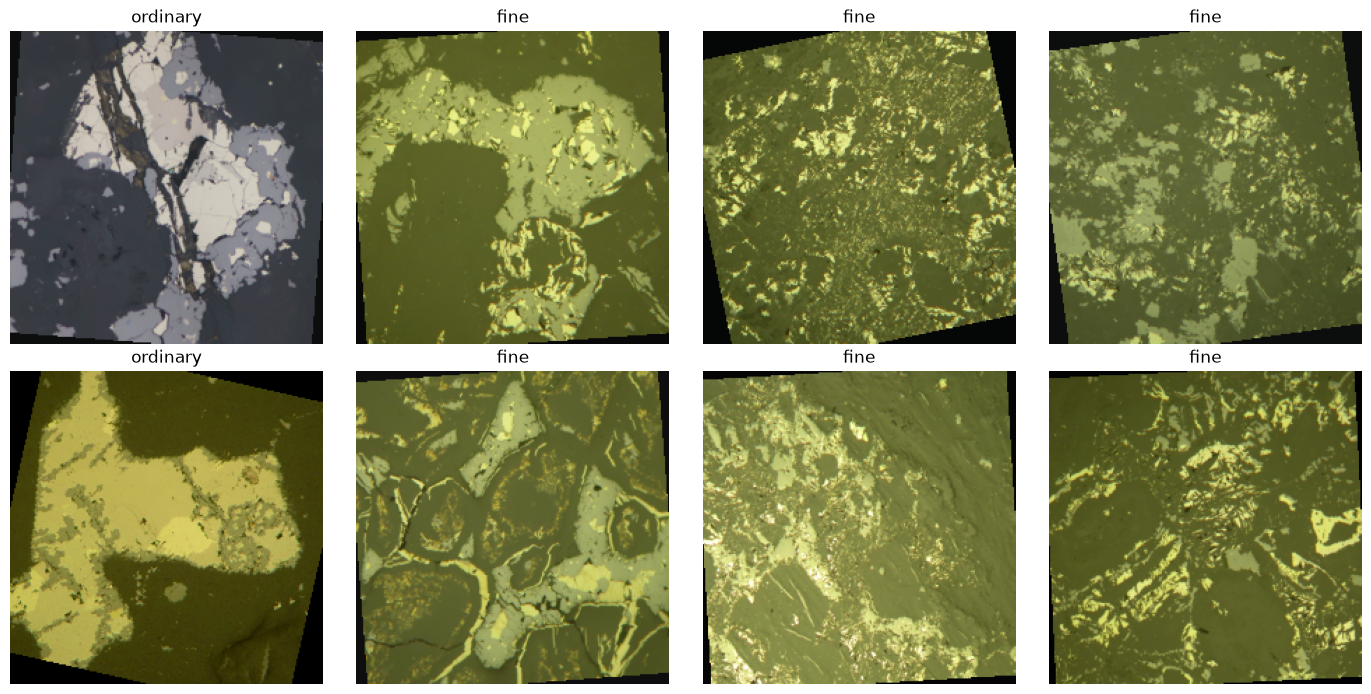

In [5]:
def denormalize(tensor: torch.Tensor) -> np.ndarray:
    image = tensor.detach().cpu().numpy().transpose(1, 2, 0)

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image = image * std + mean
    return np.clip(image, 0, 1)


batch = next(iter(loaders["train"]))

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for axis, image, label in zip(
    axes.flat,
    batch["image"][:8],
    batch["label"][:8],
):
    axis.imshow(denormalize(image))
    axis.set_title(ID_TO_LABEL[int(label)])
    axis.axis("off")

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "augmentation_preview.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

## 4. Модель

Сначала обучается только классификационная голова. Затем размораживается последняя часть feature extractor.

In [6]:
try:
    weights = models.MobileNet_V3_Small_Weights.DEFAULT
    model = models.mobilenet_v3_small(
        weights=weights,
    )
except Exception as error:
    raise RuntimeError(
        "Не удалось загрузить предобученные веса MobileNetV3. "
        "Проверьте интернет и перезапустите ячейку."
    ) from error

for parameter in model.features.parameters():
    parameter.requires_grad = False

input_features = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(
    input_features,
    len(LABEL_TO_ID),
)

model = model.to(DEVICE)

train_labels = frames["train"]["label"].map(
    LABEL_TO_ID
).to_numpy()

class_counts = np.bincount(
    train_labels,
    minlength=len(LABEL_TO_ID),
)

class_weights = (
    len(train_labels)
    / (len(LABEL_TO_ID) * class_counts)
)

criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(
        class_weights,
        dtype=torch.float32,
        device=DEVICE,
    )
)

print(model.classifier)
print("Веса классов:", class_weights)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to C:\Users\Мария/.cache\torch\hub\checkpoints\mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:02<00:00, 4.66MB/s]


Sequential(
  (0): Linear(in_features=576, out_features=1024, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1024, out_features=2, bias=True)
)
Веса классов: [1.0739645  0.93556701]


## 5. Функции обучения и оценки

In [7]:
def run_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
):
    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    losses = []
    all_true = []
    all_pred = []
    all_prob = []
    all_paths = []

    context = torch.enable_grad() if is_training else torch.no_grad()

    with context:
        for batch in tqdm(
            loader,
            leave=False,
        ):
            images = batch["image"].to(
                DEVICE,
                non_blocking=True,
            )
            labels = batch["label"].to(
                DEVICE,
                non_blocking=True,
            )

            if is_training:
                optimizer.zero_grad(set_to_none=True)

            logits = model(images)
            loss = criterion(logits, labels)

            if is_training:
                loss.backward()
                optimizer.step()

            probabilities = torch.softmax(
                logits,
                dim=1,
            )
            predictions = probabilities.argmax(dim=1)

            losses.append(
                loss.item() * len(labels)
            )
            all_true.extend(
                labels.detach().cpu().numpy()
            )
            all_pred.extend(
                predictions.detach().cpu().numpy()
            )
            all_prob.extend(
                probabilities.detach().cpu().numpy()
            )
            all_paths.extend(batch["path"])

    total = len(all_true)

    metrics = {
        "loss": sum(losses) / max(total, 1),
        "accuracy": accuracy_score(
            all_true,
            all_pred,
        ),
        "macro_f1": f1_score(
            all_true,
            all_pred,
            average="macro",
        ),
    }

    predictions_frame = pd.DataFrame({
        "path": all_paths,
        "true_id": all_true,
        "predicted_id": all_pred,
        "prob_fine": np.asarray(all_prob)[:, 0],
        "prob_ordinary": np.asarray(all_prob)[:, 1],
    })

    predictions_frame["true_label"] = (
        predictions_frame["true_id"].map(
            ID_TO_LABEL
        )
    )
    predictions_frame["predicted_label"] = (
        predictions_frame["predicted_id"].map(
            ID_TO_LABEL
        )
    )

    return metrics, predictions_frame


def train_stage(
    model,
    train_loader,
    validation_loader,
    optimizer,
    epochs,
    stage_name,
    best_f1,
):
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.4,
        patience=1,
    )

    history_rows = []

    for epoch in range(1, epochs + 1):
        started = time.time()

        train_metrics, _ = run_epoch(
            model,
            train_loader,
            criterion,
            optimizer=optimizer,
        )

        validation_metrics, validation_predictions = run_epoch(
            model,
            validation_loader,
            criterion,
        )

        scheduler.step(
            validation_metrics["macro_f1"]
        )

        row = {
            "stage": stage_name,
            "epoch": epoch,
            "seconds": time.time() - started,
            "learning_rate": optimizer.param_groups[0]["lr"],
            **{
                f"train_{key}": value
                for key, value in train_metrics.items()
            },
            **{
                f"validation_{key}": value
                for key, value in validation_metrics.items()
            },
        }

        history_rows.append(row)

        print(
            f"[{stage_name}] epoch {epoch}/{epochs} | "
            f"train F1={train_metrics['macro_f1']:.4f} | "
            f"val F1={validation_metrics['macro_f1']:.4f} | "
            f"val acc={validation_metrics['accuracy']:.4f}"
        )

        if validation_metrics["macro_f1"] > best_f1:
            best_f1 = validation_metrics["macro_f1"]

            checkpoint = {
                "model_state_dict": model.state_dict(),
                "label_to_id": LABEL_TO_ID,
                "image_size": IMAGE_SIZE,
                "architecture": "mobilenet_v3_small",
                "validation_macro_f1": best_f1,
            }

            torch.save(
                checkpoint,
                MODEL_DIR / "ordinary_fine_mobilenet_v3_small.pth",
            )

            validation_predictions.to_csv(
                OUTPUT_DIR / "best_validation_predictions.csv",
                index=False,
                encoding="utf-8-sig",
            )

    return pd.DataFrame(history_rows), best_f1

## 6. Этап 1 — обучение головы

In [8]:
optimizer = AdamW(
    (
        parameter
        for parameter in model.parameters()
        if parameter.requires_grad
    ),
    lr=LEARNING_RATE_HEAD,
    weight_decay=WEIGHT_DECAY,
)

history_head, best_f1 = train_stage(
    model=model,
    train_loader=loaders["train"],
    validation_loader=loaders["validation"],
    optimizer=optimizer,
    epochs=HEAD_EPOCHS,
    stage_name="head",
    best_f1=-1.0,
)

display(history_head)

  0%|          | 0/31 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

[head] epoch 1/4 | train F1=0.7239 | val F1=0.6891 | val acc=0.6981


  0%|          | 0/31 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

...

[head] epoch 3/4 | train F1=0.8053 | val F1=0.8397 | val acc=0.8428


  0%|          | 0/31 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

[head] epoch 4/4 | train F1=0.8313 | val F1=0.8615 | val acc=0.8616


,stage,epoch,seconds,learning_rate,train_loss,train_accuracy,train_macro_f1,validation_loss,validation_accuracy,validation_macro_f1
0,head,1,68.403727,0.001,0.532841,0.725895,0.723946,0.576482,0.698113,0.689150
1,head,2,75.724421,0.001,0.425318,0.811295,0.810630,0.410313,0.836478,0.835010
2,head,3,80.198870,0.001,0.434873,0.805785,0.805333,0.392258,0.842767,0.839698
3,head,4,75.296220,0.001,0.381461,0.831956,0.831279,0.378193,0.861635,0.861498


## 7. Этап 2 — дообучение последних блоков

In [9]:
for block in list(model.features.children())[-3:]:
    for parameter in block.parameters():
        parameter.requires_grad = True

optimizer = AdamW(
    [
        {
            "params": model.classifier.parameters(),
            "lr": LEARNING_RATE_FINETUNE,
        },
        {
            "params": [
                parameter
                for block in list(model.features.children())[-3:]
                for parameter in block.parameters()
            ],
            "lr": LEARNING_RATE_FINETUNE * 0.4,
        },
    ],
    weight_decay=WEIGHT_DECAY,
)

history_finetune, best_f1 = train_stage(
    model=model,
    train_loader=loaders["train"],
    validation_loader=loaders["validation"],
    optimizer=optimizer,
    epochs=FINETUNE_EPOCHS,
    stage_name="finetune",
    best_f1=best_f1,
)

history = pd.concat(
    [history_head, history_finetune],
    ignore_index=True,
)

history.to_csv(
    OUTPUT_DIR / "training_history.csv",
    index=False,
    encoding="utf-8-sig",
)

display(history)

  0%|          | 0/31 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

[finetune] epoch 1/4 | train F1=0.8369 | val F1=0.8860 | val acc=0.8868


  0%|          | 0/31 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

...

[finetune] epoch 3/4 | train F1=0.8671 | val F1=0.8604 | val acc=0.8616


  0%|          | 0/31 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

[finetune] epoch 4/4 | train F1=0.8923 | val F1=0.8672 | val acc=0.8679


,stage,epoch,seconds,learning_rate,train_loss,train_accuracy,train_macro_f1,validation_loss,validation_accuracy,validation_macro_f1
0,head,1,68.403727,0.00100,0.532841,0.725895,0.723946,0.576482,0.698113,0.689150
1,head,2,75.724421,0.00100,0.425318,0.811295,0.810630,0.410313,0.836478,0.835010
2,head,3,80.198870,0.00100,0.434873,0.805785,0.805333,0.392258,0.842767,0.839698
3,head,4,75.296220,0.00100,0.381461,0.831956,0.831279,0.378193,0.861635,0.861498
4,finetune,1,78.484622,0.00020,0.359205,0.837466,0.836920,0.363114,0.886792,0.886031
5,finetune,2,77.365630,0.00020,0.304000,0.859504,0.859118,0.357045,0.855346,0.853020
6,finetune,3,78.257189,0.00008,0.314851,0.867769,0.867138,0.340857,0.861635,0.860393
7,finetune,4,77.416019,0.00008,0.273264,0.892562,0.892326,0.342532,0.867925,0.867168


## 8. Графики обучения

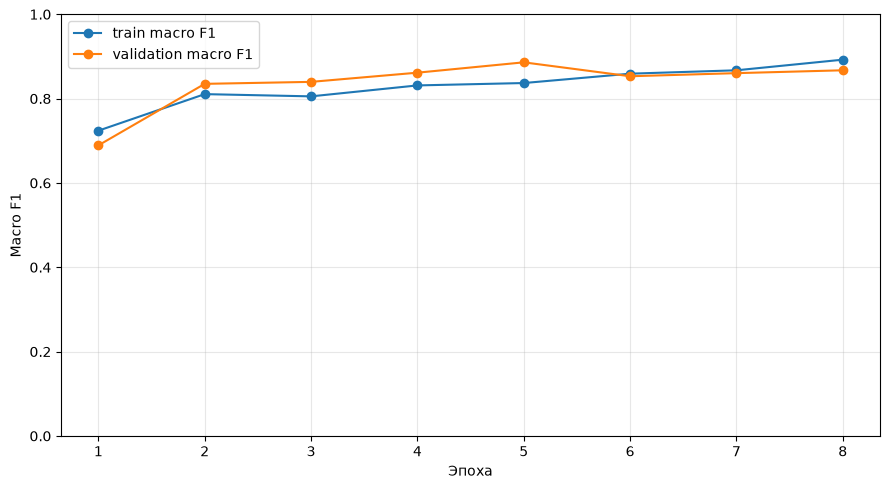

In [10]:
fig, axis = plt.subplots(figsize=(9, 5))

axis.plot(
    range(1, len(history) + 1),
    history["train_macro_f1"],
    marker="o",
    label="train macro F1",
)
axis.plot(
    range(1, len(history) + 1),
    history["validation_macro_f1"],
    marker="o",
    label="validation macro F1",
)

axis.set_xlabel("Эпоха")
axis.set_ylabel("Macro F1")
axis.set_ylim(0, 1)
axis.grid(alpha=0.3)
axis.legend()

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "training_curve.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

## 9. Итоговая оценка на test

Test используется только после выбора лучшей модели по validation.

In [11]:
checkpoint_path = (
    MODEL_DIR / "ordinary_fine_mobilenet_v3_small.pth"
)

checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE,
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

test_metrics, test_predictions = run_epoch(
    model,
    loaders["test"],
    criterion,
)

test_predictions.to_csv(
    OUTPUT_DIR / "test_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)

print("TEST METRICS")
print(json.dumps(test_metrics, indent=2))

report = classification_report(
    test_predictions["true_id"],
    test_predictions["predicted_id"],
    target_names=[
        ID_TO_LABEL[index]
        for index in range(len(ID_TO_LABEL))
    ],
    output_dict=True,
    zero_division=0,
)

report_frame = pd.DataFrame(report).T
report_frame.to_csv(
    OUTPUT_DIR / "test_classification_report.csv",
    encoding="utf-8-sig",
)

display(report_frame)

  0%|          | 0/5 [00:00<?, ?it/s]

TEST METRICS
{
  "loss": 0.4723092516263326,
  "accuracy": 0.8333333333333334,
  "macro_f1": 0.8333333333333334
}


,precision,recall,f1-score,support
fine,0.789474,0.882353,0.833333,51.000000
ordinary,0.882353,0.789474,0.833333,57.000000
accuracy,0.833333,0.833333,0.833333,0.833333
macro avg,0.835913,0.835913,0.833333,108.000000
weighted avg,0.838493,0.833333,0.833333,108.000000


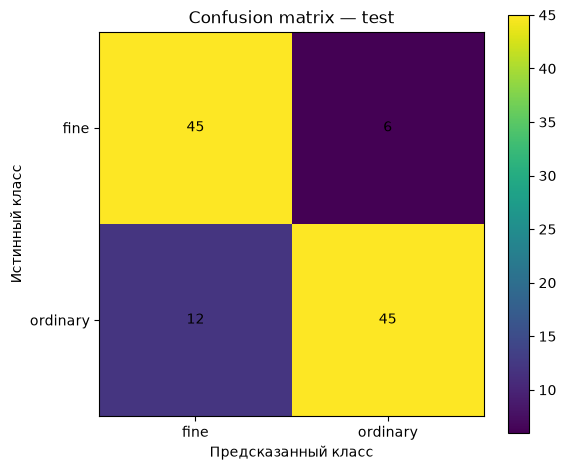

In [12]:
matrix = confusion_matrix(
    test_predictions["true_id"],
    test_predictions["predicted_id"],
)

fig, axis = plt.subplots(figsize=(6, 5))

image = axis.imshow(matrix)

axis.set_xticks([0, 1], ["fine", "ordinary"])
axis.set_yticks([0, 1], ["fine", "ordinary"])
axis.set_xlabel("Предсказанный класс")
axis.set_ylabel("Истинный класс")
axis.set_title("Confusion matrix — test")

for row in range(matrix.shape[0]):
    for col in range(matrix.shape[1]):
        axis.text(
            col,
            row,
            str(matrix[row, col]),
            ha="center",
            va="center",
        )

fig.colorbar(image, ax=axis)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "test_confusion_matrix.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

## 10. Самые неуверенные и ошибочные примеры

In [13]:
test_predictions["confidence"] = test_predictions[
    ["prob_fine", "prob_ordinary"]
].max(axis=1)

errors = test_predictions[
    test_predictions["true_label"]
    != test_predictions["predicted_label"]
].sort_values("confidence", ascending=False)

uncertain = test_predictions.sort_values(
    "confidence",
    ascending=True,
)

errors.to_csv(
    OUTPUT_DIR / "test_errors.csv",
    index=False,
    encoding="utf-8-sig",
)

uncertain.head(30).to_csv(
    OUTPUT_DIR / "test_most_uncertain.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Ошибок на test:", len(errors))
display(errors.head(20))

Ошибок на test: 18


,path,true_id,predicted_id,prob_fine,prob_ordinary,true_label,predicted_label,confidence
85,C:\Users\Мария\ore_hackathon\data\raw\Фото руд...,0,1,0.003561,0.996439,fine,ordinary,0.996439
77,C:\Users\Мария\ore_hackathon\data\raw\Фото руд...,0,1,0.020478,0.979522,fine,ordinary,0.979522
72,C:\Users\Мария\ore_hackathon\data\raw\Фото руд...,0,1,0.035473,0.964527,fine,ordinary,0.964527
15,C:\Users\Мария\ore_hackathon\data\raw\Фото руд...,0,1,0.057145,0.942855,fine,ordinary,0.942855
50,C:\Users\Мария\ore_hackathon\data\raw\Фото руд...,1,0,0.900921,0.099079,ordinary,fine,0.900921
51,C:\Users\Мария\ore_hackathon\data\raw\Фото руд...,1,0,0.900135,0.099865,ordinary,fine,0.900135
59,C:\Users\Мария\ore_hackathon\data\raw\Фото руд...,1,0,0.841044,0.158956,ordinary,fine,0.841044
34,C:\Users\Мария\ore_hackathon\data\raw\Фото руд...,1,0,0.795173,0.204827,ordinary,fine,0.795173
63,C:\Users\Мария\ore_hackathon\data\raw\Фото руд...,1,0,0.793418,0.206582,ordinary,fine,0.793418
28,C:\Users\Мария\ore_hackathon\data\raw\Фото руд...,1,0,0.781775,0.218225,ordinary,fine,0.781775


## Что прислать после выполнения

- `outputs/classifier/training_history.csv`;
- `outputs/classifier/test_classification_report.csv`;
- `outputs/classifier/test_confusion_matrix.png`;
- `outputs/classifier/test_errors.csv`;
- последнюю строку с test metrics.

После этого подключаем модель к анализу тайлов панорамы.

In [14]:
print("=" * 72)
print("ОБУЧЕНИЕ ЗАВЕРШЕНО")
print("=" * 72)
print(
    "Лучшая validation macro F1:",
    f"{checkpoint['validation_macro_f1']:.4f}",
)
print(
    "Test macro F1:",
    f"{test_metrics['macro_f1']:.4f}",
)
print(
    "Test accuracy:",
    f"{test_metrics['accuracy']:.4f}",
)
print("Модель:", checkpoint_path.resolve())
print("Отчёты:", OUTPUT_DIR.resolve())

ОБУЧЕНИЕ ЗАВЕРШЕНО
Лучшая validation macro F1: 0.8860
Test macro F1: 0.8333
Test accuracy: 0.8333
Модель: C:\Users\Мария\ore_hackathon\models\ordinary_fine_mobilenet_v3_small.pth
Отчёты: C:\Users\Мария\ore_hackathon\outputs\classifier
